# **Evaluación 1 - Machine Learning**


## **Sección 1**

Genere las siguientes imágenes de manera sintética. \\

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

In [ ]:
# Import some libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio
from google.colab.patches import cv2_imshow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Ejercicio 1 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1Z3yNgkQVFJyaCRyTzkjFhIB_3kxqs61q/view?usp=drive_link). \\
**NOTA:** En la salida de la celda puede encontrar el tamaño de la imagen final.

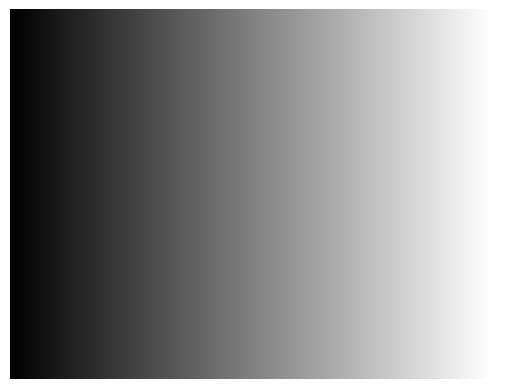

In [ ]:
# Lea la imagen

alto = 389
ancho = 515

# Crear fondo blanco (matriz)
img = np.ones((alto, ancho, 3), dtype=np.uint8) * 255

# Dimensiones del rectángulo con degradado
top = 9
bottom = 379
left = 10
right = 491

h = bottom - top
w = right - left

# Crear degradado horizontal usando arreglos
gradient = np.linspace(0, 255, w).astype(np.uint8)

# Convertir el degradado en una matriz 2D repitiéndolo en vertical
gradient_matrix = np.tile(gradient, (h, 1))

# Convertir a imagen RGB
gradient_rgb = np.stack((gradient_matrix,)*3, axis=-1)

# Insertar el degradado dentro del fondo blanco
img[top:bottom, left:right] = gradient_rgb

# Mostrar la imagen
cv2_imshow(img)

### **Ejercicio 2 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/13z0tvGYD-37_PuHOqoRWHGGmGq7xxvU7/view?usp=drive_link).

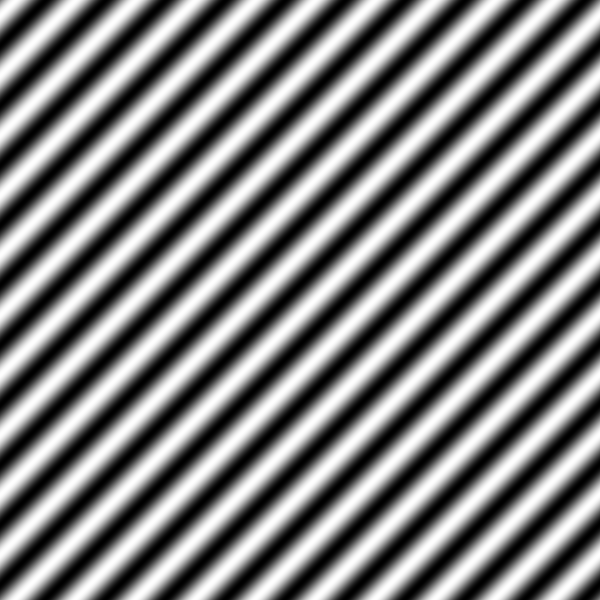

In [ ]:
# Tamaño de la imagen
n = 600

# Crear coordenadas (matrices)
x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)

X, Y = np.meshgrid(x, y)

# Crear patrón de franjas diagonales usando seno
frecuencia = 10
pattern = np.sin(2 * np.pi * frecuencia * (X + Y))

# Normalizar a rango 0–255
pattern_norm = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

# Convertir a imagen RGB
img = np.stack((pattern_norm,)*3, axis=-1)

# Mostrar imagen
cv2_imshow(img)

## **Sección 2**

Genere las siguientes imágenes usando recorridos por píxeles a partir de [lena.jpg](https://drive.google.com/file/d/1gH5sJN__2g7f9ndLhLvTECdOBJIGUbg_/view?usp=sharing)  y [bengal_tiger.jpg](https://drive.google.com/file/d/1oz8CWUjN7UBNJNq1XOxqzwmYcJRTRmxr/view?usp=sharing)

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

### **Ejercicio 3 (C = 1.6)**

Genere la siguiente animación [resultado](https://drive.google.com/file/d/1jSNhV2CYdm6-E5wuo7o5wE-b2J-_mEil/view?usp=drive_link).

In [ ]:
# Cargar imágenes
lena = cv2.imread('lena.jpg')
tigre = cv2.imread('Tigre.jpg')

# Asegurar mismo tamaño
h, w, c = lena.shape
tigre = cv2.resize(tigre, (w, h))

frames = []

# Generar transición Lena -> Tigre
num_frames = 20

for k in range(num_frames):

    alpha = k / (num_frames - 1)

    nueva = np.zeros((h, w, c), dtype=np.uint8)

    # Recorrido por píxeles
    for i in range(h):
        for j in range(w):
            for ch in range(c):
                nueva[i, j, ch] = int(
                    (1 - alpha) * lena[i, j, ch] +
                    alpha * tigre[i, j, ch]
                )

    frames.append(nueva)

# Guardar GIF
imageio.mimsave('transicion_lena_tigre.gif', frames, duration=0.1)

print("GIF creado: transicion_lena_tigre.gif")

GIF creado: transicion_lena_tigre.gif


### **Ejercicio 4 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1UX2Y8Q2xWy5ej0hl_r1B-fKAQ8SX5DI1/view?usp=drive_link).

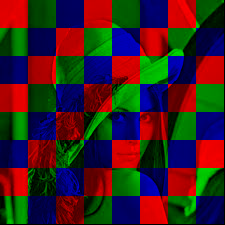

In [11]:
# Cargar imagen
lena = cv2.imread('lena.jpg')

h, w, c = lena.shape

# Tamaño de los bloques (8x8 como en la imagen)
bloques = 8
bh = h // bloques
bw = w // bloques

# Crear imagen resultado
resultado = np.zeros((h, w, c), dtype=np.uint8)

for i in range(bloques):
    for j in range(bloques):

        # seleccionar canal (R,G,B)
        color = (i + j) % 3

        for y in range(i*bh, (i+1)*bh):
            for x in range(j*bw, (j+1)*bw):

                if color == 0:  # rojo
                    resultado[y,x,2] = lena[y,x,2]
                    resultado[y,x,1] = 0
                    resultado[y,x,0] = 0

                elif color == 1:  # verde
                    resultado[y,x,1] = lena[y,x,1]
                    resultado[y,x,2] = 0
                    resultado[y,x,0] = 0

                else:  # azul
                    resultado[y,x,0] = lena[y,x,0]
                    resultado[y,x,1] = 0
                    resultado[y,x,2] = 0

# Mostrar resultado
cv2_imshow(resultado)

### **Ejercicio 5 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/10jxoa_muSn6bxsDBy7Vw88wz1oirMiRH/view?usp=drive_link)

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

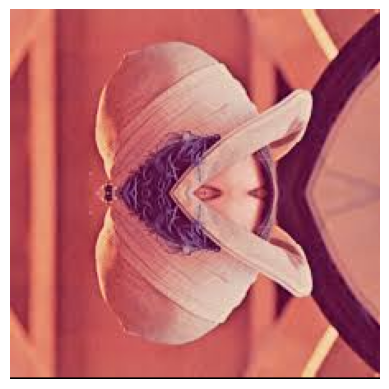

In [12]:
# 1. Cargar la imagen
img = cv2.imread('lena.jpg')

# 2. Convertir de BGR a RGB (solo para visualizar bien con matplotlib)
img = img[:,:,::-1]

# 3. Obtener dimensiones de la imagen
h, w, c = img.shape

# 4. Crear matriz vacía para la imagen resultado
result = np.zeros((h, w, c), dtype=img.dtype)

# 5. Copiar la mitad superior de la imagen original
for i in range(h//2):
    for j in range(w):
        result[i, j] = img[i, j]

# 6. Crear la mitad inferior como espejo vertical de la mitad superior
for i in range(h//2):
    for j in range(w):
        result[h//2 + i, j] = img[h//2 - 1 - i, j]

# 7. Mostrar la imagen resultado
plt.imshow(result)
plt.axis('off')